<span>
<b>Author:</b> <a href="http://andreafailla.github.io">Andrea Failla</a><br/>
<b>Python version:</b>  >=3.9<br/>
<b>Networkx version:</b>  >=3<br/>
<b>Last update:</b> 27/03/2026
</span>

<a id='top'></a>
# (Social) Network Analysis with NetworkX

``Networkx`` is a Python library designed to support analysis of complex networks.

This notebook introduces core concepts and a practical workflow using real social data.


## Goals and outline

**Goals**:
- Build and explore graphs with NetworkX.
- Analyze degree distribution and assortativity.
- Measure homophily with node attributes.
- Detect communities and interpret modularity.
- Demonstrate the friendship paradox.

In [24]:
from __future__ import annotations

from pathlib import Path
import urllib.request
import random

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
random.seed(42)
np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 4)

REPO_ROOT = Path.cwd()
DATA_DIR = REPO_ROOT / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

FB_URL = "https://snap.stanford.edu/data/facebook_combined.txt.gz"
FB_PATH = DATA_DIR / "facebook_combined.txt.gz"


def download_if_needed(url: str, path: Path) -> None:
    if path.exists():
        return
    print(f"Downloading {url} -> {path}")
    urllib.request.urlretrieve(url, path)


## 1. Warm-up: a tiny graph

Start with a minimal example to understand nodes, edges, and visualization.


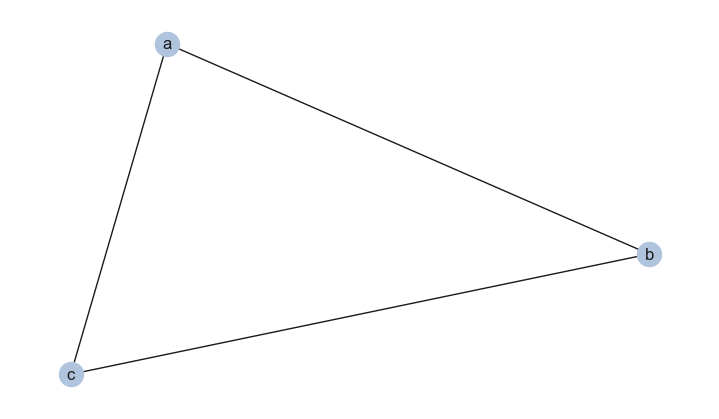

In [25]:
g = nx.Graph()

g.add_edge("a", "b")
g.add_edge("a", "c")
g.add_edge("b", "c")

nx.draw(g, with_labels=True, node_color="lightsteelblue")
plt.show()


Nodes and edges can also be easly removed

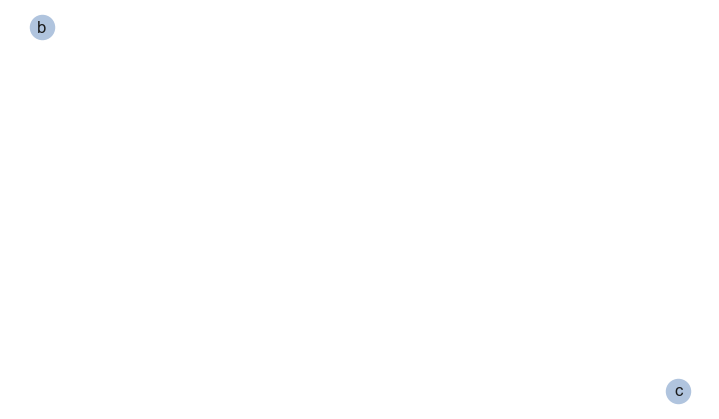

In [26]:
g.remove_node("a")
g.remove_edge("b", "c")

#re-draw the graph
nx.draw(g, with_labels=True, node_color="lightsteelblue")

## Reading a graph from file
``networkx`` natively supports several network file formats.

Among them one the most frequently used in online repositories is the *edgelist* one.

An edge list is a text file (usually saved as .csv or .txt) in which each line identifies an edge. <br/>
For instance, the triangle defined before can be described as:

    a,b
    b,c
    c,a

In [27]:
download_if_needed(FB_URL, FB_PATH) # this will download the Facebook dataset if it doesn't already exist

To read edgelist file just write

In [71]:
G = nx.read_edgelist(FB_PATH, create_using=nx.Graph(), nodetype=int)
print(G)

Graph with 4039 nodes and 88234 edges


Similarly a graph can be written to file using ``nx.write_edgelist(g, filename)``.

For all the I/O methods refer to the [official documentation](https://networkx.github.io/documentation/latest/reference/readwrite/index.html)

A quick visualization of a small sample of nodes helps build intuition.


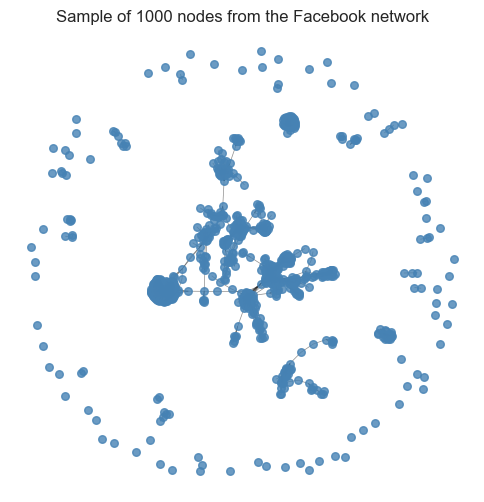

In [102]:
size = 1000
sample_nodes = list(np.random.choice(list(G.nodes()), size=size, replace=False))
H = G.subgraph(sample_nodes)

pos = nx.spring_layout(H, seed=42)
plt.figure(figsize=(6, 6))
nx.draw_networkx_nodes(H, pos, node_size=30, node_color="steelblue", alpha=0.8)
nx.draw_networkx_edges(H, pos, width=0.5, alpha=0.5)
plt.title(f"Sample of {size} nodes from the Facebook network")
plt.axis("off")
plt.show()


## Accessing nodes and edges
Given a ``Graph`` object is it possible to iterate over its nodes with a simple ``for`` loop

In [73]:
for n in G.nodes():
    # do something
    pass

Following a similar rationale is it also possible to loop over the edge set

In [74]:
for e in G.edges():
    # do something
    pass

All graph entities can be used to store additional attributes (weights, labels...). 

For furhter details refer to the [official documentation](https://networkx.github.io/documentation/latest/tutorial.html#adding-attributes-to-graphs-nodes-and-edges)

## Network base statistics
``networkx`` allows to manipulate nodes as well as edges, count them, and extract relevant global features.

In [75]:
G.number_of_nodes()

4039

In [76]:
G.number_of_edges()

88234

In [77]:
G.is_directed()

False

## Degrees and Degree distribution
Node degree can be easily obtained as follows:

In [78]:
G.degree(1) # degree for node 1

17

Similarly the average degree can be computed with

In [103]:
degrees = [G.degree(n) for n in G.nodes()] # degree for all nodes
np.mean(degrees)

43.69101262688784

An easy way to compute, and visualise, the degree distribution is the following

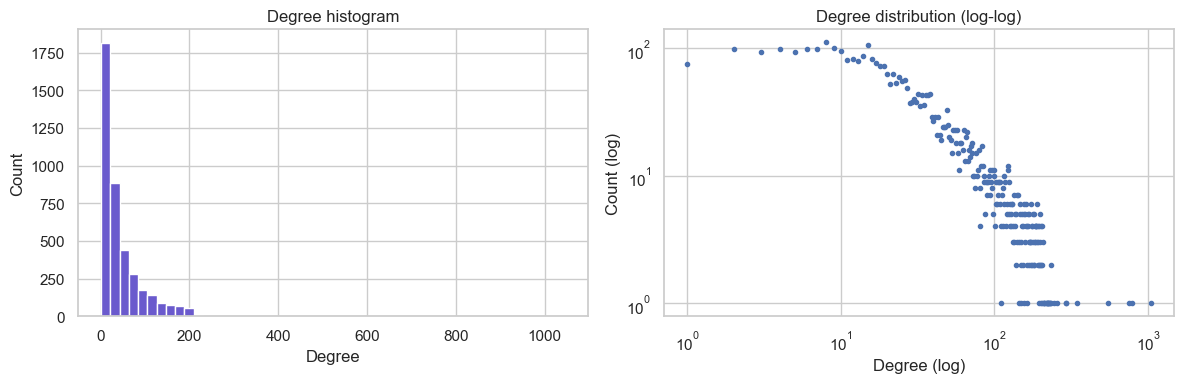

count    4039.000000
mean       43.691013
std        52.420605
min         1.000000
25%        11.000000
50%        25.000000
75%        57.000000
max      1045.000000
dtype: float64

In [80]:
degrees = np.array([d for _, d in G.degree()])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: standard histogram
axes[0].hist(degrees, bins=50, color="slateblue")
axes[0].set_xlabel("Degree")
axes[0].set_ylabel("Count")
axes[0].set_title("Degree histogram")

# Right: degree distribution on log-log axes
deg_values, deg_counts = np.unique(degrees, return_counts=True)
axes[1].loglog(deg_values, deg_counts, marker=".", linestyle="none")
axes[1].set_xlabel("Degree (log)")
axes[1].set_ylabel("Count (log)")
axes[1].set_title("Degree distribution (log-log)")

plt.tight_layout()
plt.show()

pd.Series(degrees).describe()


**Exercise**: Change the threshold and compute the fraction of nodes with degree above that threshold.


In [81]:
threshold = 100  # change me
fraction = (degrees >= threshold).mean()
print(f"{fraction:.2%} of nodes have degree >= {threshold}")


12.16% of nodes have degree >= 100


## Graph components
``networkx`` allows to select node specific views of the original graph

In [82]:
list(G.neighbors(100)) # obtain the list of neighobors for node 100

[0, 64, 119, 150, 163, 189, 217, 269, 323]

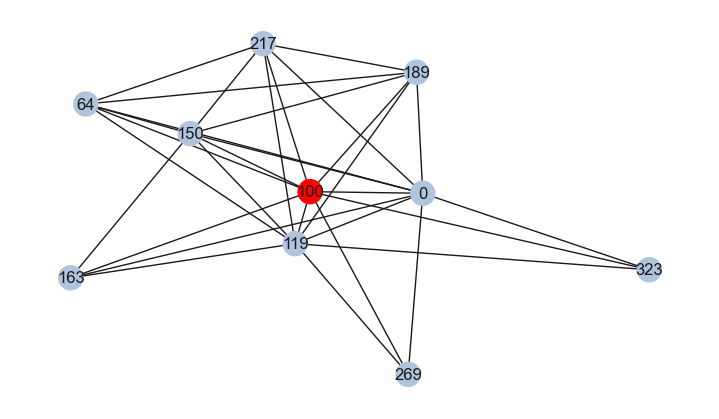

In [83]:
ego = nx.ego_graph(G, 100) # ego network of the node 100
# color the ego node differently
node_colors = ["red" if n == 100 else "lightsteelblue" for n in ego.nodes()]
pos = nx.spring_layout(ego, seed=0)
nx.draw(ego, pos=pos, with_labels=True, node_color=node_colors)

Using the same rationale also connected components can be extracted

In [84]:
nx.number_connected_components(g)

2

## Paths and Diameter
Shortest paths can be extracted as well using the following syntax

In [86]:
nx.shortest_path(ego, source=163, target=323)

[163, 0, 323]

In [87]:
nx.shortest_path_length(ego, source=163, target=323)

2

Moreover, the network diameter can be computed as follows

In [88]:
nx.diameter(ego) # longest shortest path in the ego network

2

## Triangles, density and clustering
Other indexes that can be computed using the library are 

In [90]:
nx.density(G) # fraction of possible edges that are present in the graph

0.010819963503439287

In [92]:
nx.triangles(G)[0] # count the triangles each node is involved in (and access the value of node 0)

2519

In [93]:
nx.clustering(G)[0] # compute the local clustering coefficient for all nodes (and access the value for node 0)
# lcc is the fraction of possible triangles through that node that actually exist

0.04196165314587463

In [95]:
nx.average_clustering(G) # compute the global clustering coefficient
# global clustering coefficient is the average of the local clustering coefficients across all nodes

0.6055467186200876

## Assortativity and homophily

Assortativity measures whether nodes connect to similar nodes. Degree assortativity uses degree as the attribute.


In [89]:
degree_assortativity = nx.degree_assortativity_coefficient(G)
print(f"Degree assortativity: {degree_assortativity:.3f}")


Degree assortativity: 0.064


Homophily is assortativity on an explicit node attribute. We use the Karate Club dataset, where each node has a `club` attribute.


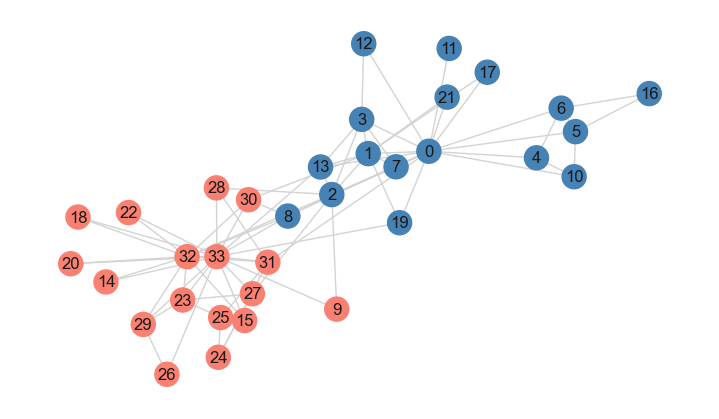

In [21]:
K = nx.karate_club_graph()
clubs = nx.get_node_attributes(K, "club")

# draw
color_map = {"Mr. Hi": "steelblue", "Officer": "salmon"}
node_colors = [color_map[clubs[node]] for node in K.nodes()]
nx.draw(K, with_labels=True, node_color=node_colors, edge_color="lightgray")
plt.show()


In [22]:
club_assortativity = nx.attribute_assortativity_coefficient(K, "club")
print(f"Attribute assortativity (club): {club_assortativity:.3f}")

labels = sorted(set(clubs.values()))
mix = nx.attribute_mixing_matrix(K, "club", mapping={label: i for i, label in enumerate(labels)})

mix_df = pd.DataFrame(mix, index=labels, columns=labels)
mix_df

Attribute assortativity (club): 0.718


,Mr. Hi,Officer
Mr. Hi,0.448718,0.070513
Officer,0.070513,0.410256


## 5. Communities

We detect communities using greedy modularity optimization and inspect community sizes.


Communities found: 13
Modularity: 0.777


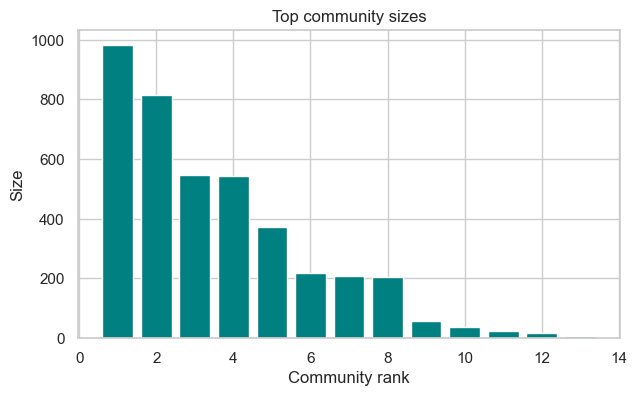

In [96]:
from networkx.algorithms.community import greedy_modularity_communities, modularity

communities = list(greedy_modularity_communities(G))
mod_score = modularity(G, communities)

sizes = sorted([len(c) for c in communities], reverse=True)
print(f"Communities found: {len(communities)}")
print(f"Modularity: {mod_score:.3f}")

k = min(15, len(sizes))
plt.bar(range(1, k + 1), sizes[:k], color="teal")
plt.xlabel("Community rank")
plt.ylabel("Size")
plt.title("Top community sizes")
plt.show()


This is just one of (many!!!) algorithms for community detection. A python library that allows you to use more advanced methods, and also to evaluate and compare different partitions is [cdlib](https://cdlib.readthedocs.io/en/latest/).

## 6. Friendship paradox

The friendship paradox says that, on average, your friends have more friends than you do.


In [100]:
deg = dict(G.degree())
avg_nbr_deg = {}
for n in G.nodes():
    # for each node, get its neighbors
    nbrs = G.neighbors(n)
    # compute the average degree of the neighbors, handling the case where a node has no neighbors
    avg_nbr_deg[n] = np.mean([deg[nbr] for nbr in nbrs]) if G.degree(n) > 0 else 0

avg_degree = np.mean(list(deg.values()))
avg_neighbor_degree = np.mean(list(avg_nbr_deg.values()))

paradox_count = sum(avg_nbr_deg[n] > deg[n] for n in G.nodes())
paradox_pct = paradox_count / G.number_of_nodes() * 100

print(f"Average degree: {avg_degree:.2f}")
print(f"Average neighbor degree: {avg_neighbor_degree:.2f}")
print(f"Percent of nodes whose neighbors are more connected: {paradox_pct:.1f}%")


Average degree: 43.69
Average neighbor degree: 105.55
Percent of nodes whose neighbors are more connected: 87.5%
